**Timeseries**

**Part1: Data Preparation and Exploration**

Data loading


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('exchange_rate.csv')
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


In [4]:
#check shape
print(df.shape[0])
print(df.shape[1])

7588
2


In [5]:
print(df.columns)

Index(['date', 'Ex_rate'], dtype='object')


Parse Date Column

In [6]:
# Convert date column into datetime format
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
# Display first few rows
df.head()

,date,Ex_rate
0,1990-01-01,0.7855
1,1990-01-02,0.7818
2,1990-01-03,0.7867
3,1990-01-04,0.7860
4,1990-01-05,0.7849


In [7]:
# Set date as index
df.set_index('date', inplace=True)
# Sort data according to date
df.sort_index(inplace=True)
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


Initial Exploration

In [8]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [9]:
df.isnull().sum()

Ex_rate    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(2258)

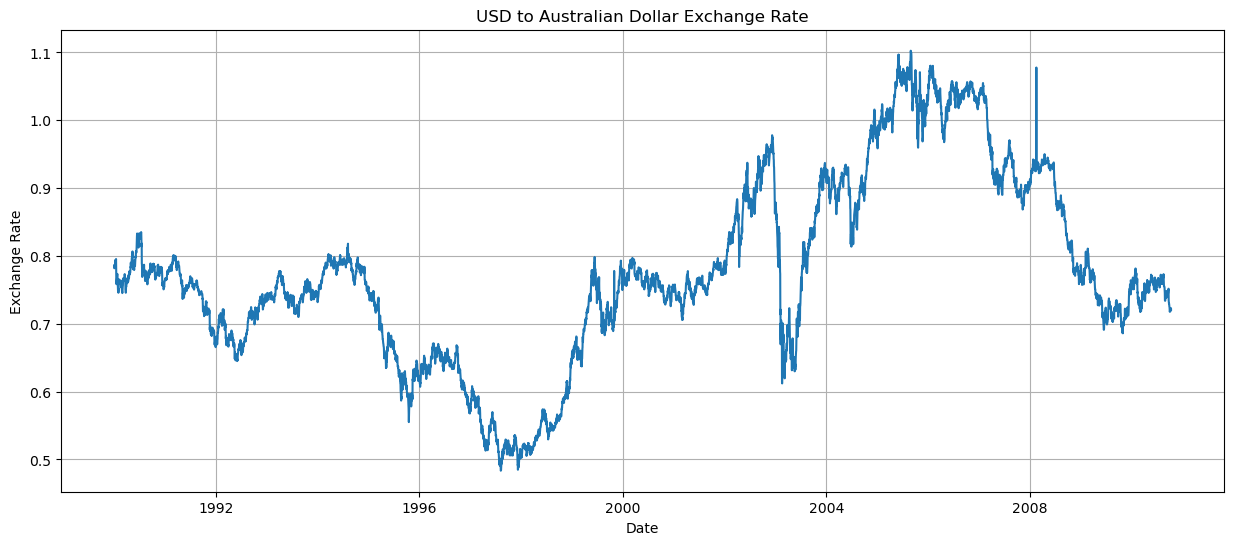

In [11]:
#plot exchange rate
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Ex_rate'])
plt.title('USD to Australian Dollar Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True)
plt.show()

Data Preprocessing

In [12]:
#check missing value
print(df.isnull().sum())

Ex_rate    0
dtype: int64


In [13]:
df['Ex_rate']=df['Ex_rate'].ffill()
print(df.isnull().sum())

Ex_rate    0
dtype: int64


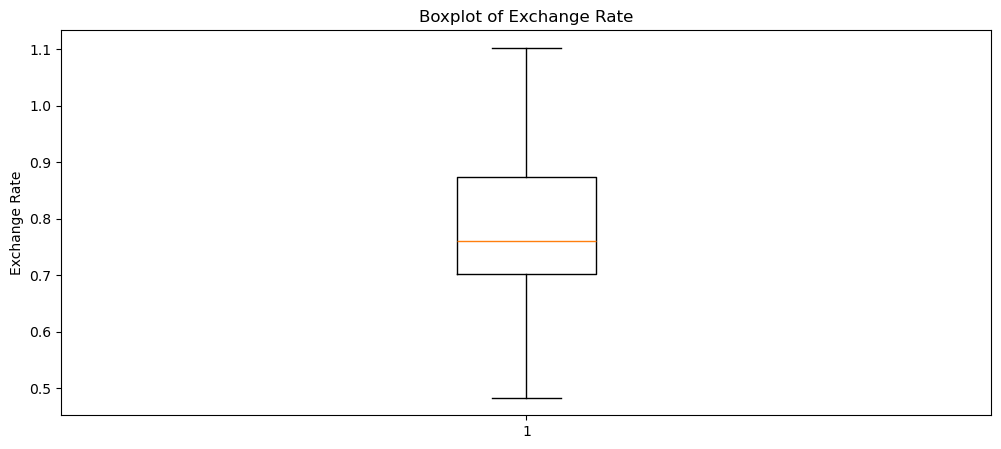

In [14]:
plt.figure(figsize=(12, 5))
plt.boxplot(df['Ex_rate'].dropna())
plt.title('Boxplot of Exchange Rate')
plt.ylabel('Exchange Rate')
plt.show()

In [15]:
Q1 = df['Ex_rate'].quantile(0.25)
Q3 = df['Ex_rate'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[
    (df['Ex_rate'] < lower_bound) |
    (df['Ex_rate'] > upper_bound)
]
print("Number of outliers:", len(outliers))

Number of outliers: 0


**Part2: Model Building-ARIMA**

Parameter selection of arima

In [16]:
# Create time series
series = df['Ex_rate']
# Calculate split point
split = int(len(series) * 0.80)
# Train and test data
train = series[:split]
test = series[split:]
print("Training data:", len(train))
print("Testing data:", len(test))

Training data: 6070
Testing data: 1518


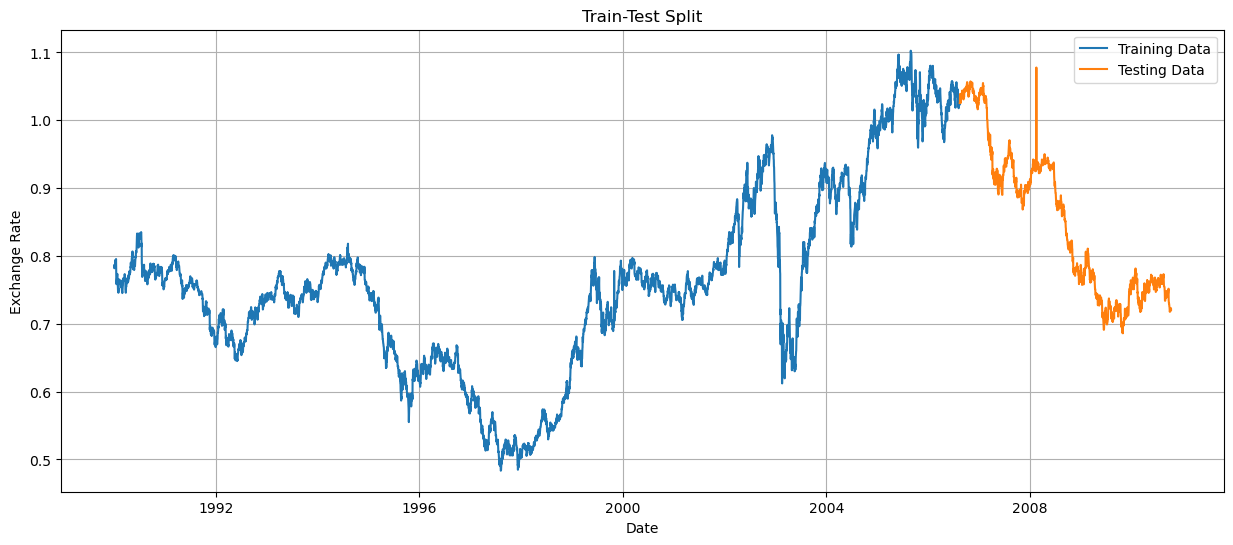

In [18]:
#visualize train and test data
plt.figure(figsize=(15, 6))
plt.plot(train, label='Training Data')
plt.plot(test, label='Testing Data')
plt.title('Train-Test Split')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
from statsmodels.tsa.stattools import adfuller
# Augmented Dickey-Fuller test
result = adfuller(train.dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.9808550190078951
p-value: 0.7601827946372046


In [20]:
if result[1] <= 0.05:
    print("The series is stationary.")
else:
    print("The series is not stationary.")

The series is not stationary.


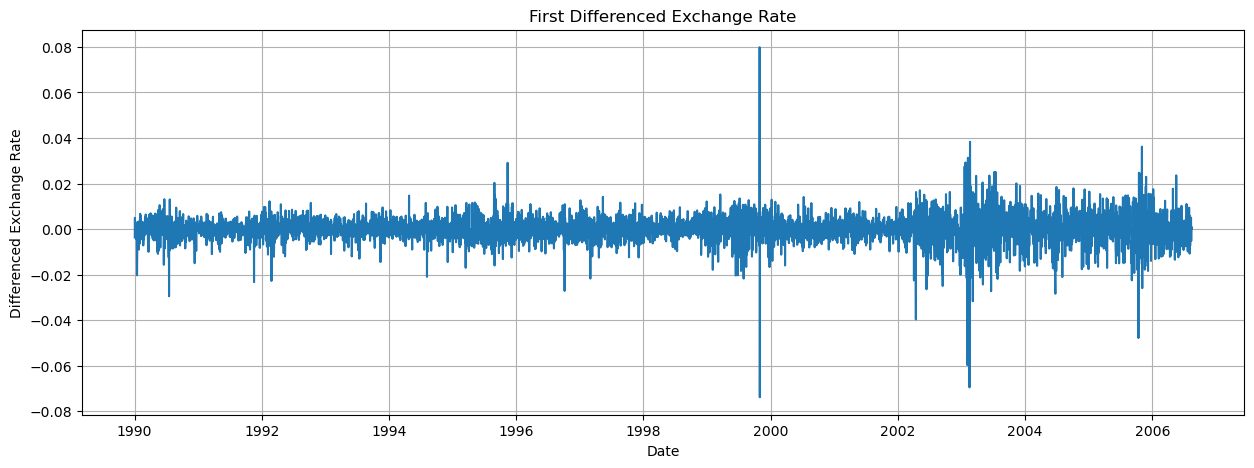

In [21]:
# First differencing
train_diff = train.diff().dropna()

# Plot differenced data
plt.figure(figsize=(15, 5))
plt.plot(train_diff)
plt.title('First Differenced Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Differenced Exchange Rate')
plt.grid(True)
plt.show()

In [22]:
result_diff = adfuller(train_diff)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

ADF Statistic: -27.33600146380152
p-value: 0.0


In [23]:
if result_diff[1] <= 0.05:
    print("Differenced series is stationary.")
else:
    print("Differenced series is still not stationary.")

Differenced series is stationary.


<Figure size 1200x500 with 0 Axes>

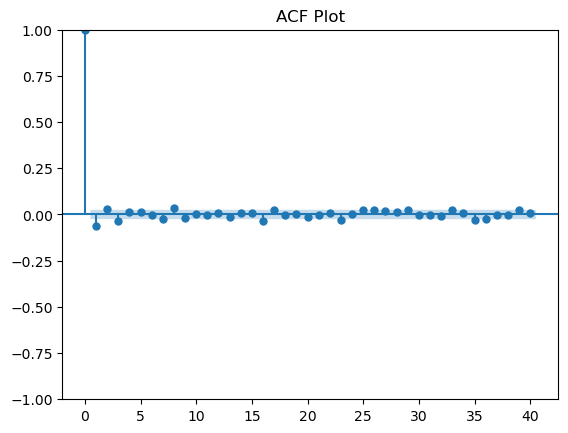

In [24]:
#ACF plot
from statsmodels.graphics.tsaplots import plot_acf
plt.figure(figsize=(12, 5))
plot_acf(train_diff, lags=40)
plt.title('ACF Plot')
plt.show()


<Figure size 1200x500 with 0 Axes>

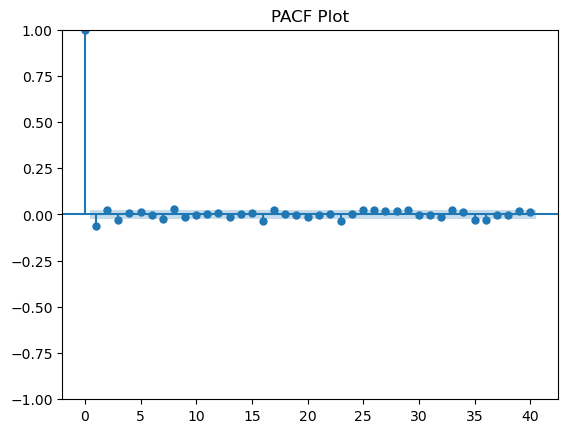

In [25]:
#PACF plot
from statsmodels.graphics.tsaplots import plot_pacf
plt.figure(figsize=(12, 5))
plot_pacf(train_diff, lags=40, method='ywm')
plt.title('PACF Plot')
plt.show()

ACF helps estimate the q parameter.

PACF helps estimate the p parameter.

Differencing determines d.

In [28]:
#ARIMA Model fitting
from statsmodels.tsa.arima.model import ARIMA
import warnings
# Fit ARIMA model
arima_model = ARIMA(train, order=(1, 1, 1))
arima_result = arima_model.fit()
# Display model summary
print(arima_result.summary())

C:\Users\AKASH\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\AKASH\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\AKASH\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Sun, 16 Aug 2026   AIC                         -45432.092
Time:                        13:35:23   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

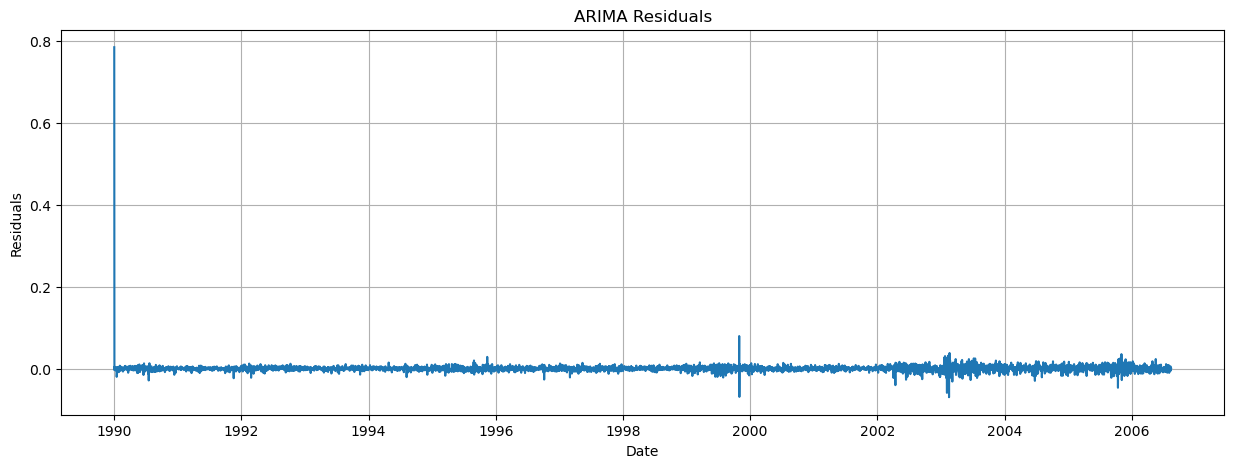

In [29]:
#ARIMA Diagnostics
# Get residuals
residuals = arima_result.resid
# Plot residuals
plt.figure(figsize=(15, 5))
plt.plot(residuals)
plt.title('ARIMA Residuals')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.grid(True)

plt.show()

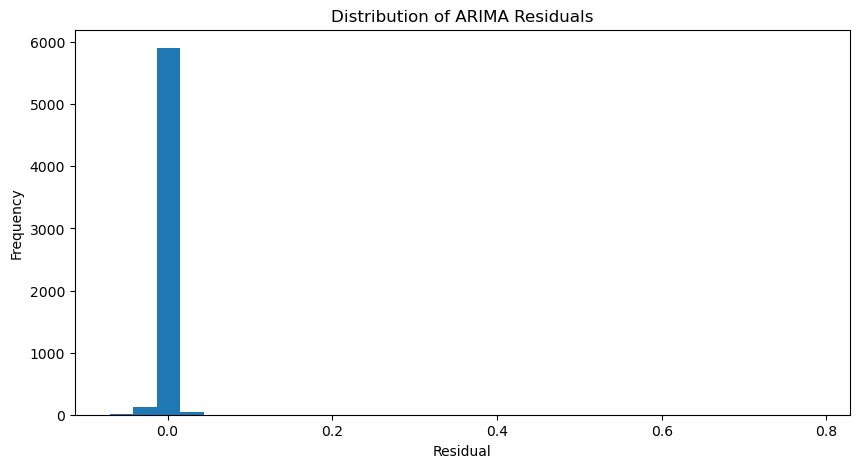

In [30]:
#residual dist
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=30)
plt.title('Distribution of ARIMA Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

<Figure size 1200x500 with 0 Axes>

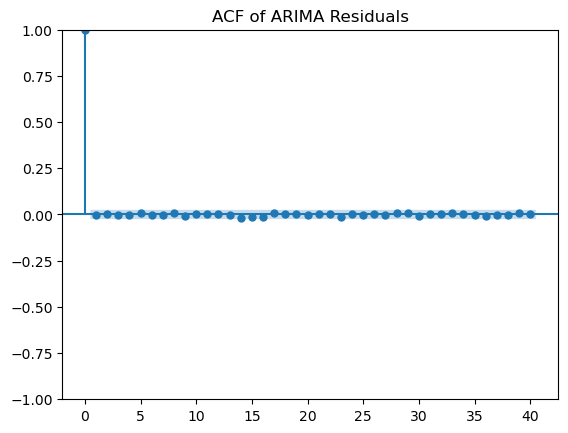

In [31]:
plt.figure(figsize=(12, 5))
plot_acf(residuals.dropna(), lags=40)
plt.title('ACF of ARIMA Residuals')
plt.show()

In [32]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    residuals.dropna(),
    lags=[10, 20],
    return_df=True
)
ljung_box

,lb_stat,lb_pvalue
10,1.647217,0.998399
20,5.913127,0.999010


In [33]:
# Forecast for the length of test data
arima_forecast = arima_result.forecast(steps=len(test))
# Convert forecast to Series
arima_forecast = pd.Series(
    arima_forecast,
    index=test.index
)
arima_forecast.head()

date
2006-08-15    1.023685
2006-08-16    1.023606
2006-08-17    1.023653
2006-08-18    1.023625
2006-08-19    1.023642
Name: predicted_mean, dtype: float64

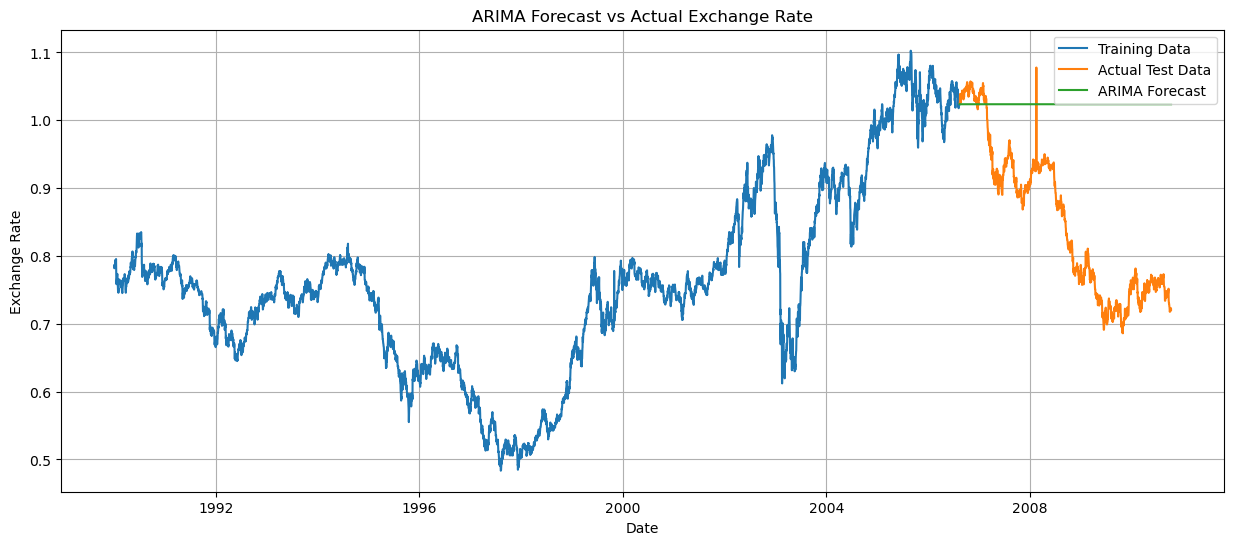

In [34]:
plt.figure(figsize=(15, 6))
plt.plot(train, label='Training Data')
plt.plot(test, label='Actual Test Data')
plt.plot(arima_forecast, label='ARIMA Forecast')
plt.title('ARIMA Forecast vs Actual Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)

plt.show()

**Part3:Evaluation and Comparision**

In [35]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

Compute error Metrics

In [39]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit Exponential Smoothing model
exp_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None
)
exp_result = exp_model.fit()
print(exp_result.summary())

C:\Users\AKASH\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 6070
Model:             ExponentialSmoothing   SSE                              0.199
Optimized:                         True   AIC                         -62655.663
Trend:                         Additive   BIC                         -62628.819
Seasonal:                          None   AICC                        -62655.650
Seasonal Periods:                  None   Date:                 Sun, 16 Aug 2026
Box-Cox:                          False   Time:                         13:55:01
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9428890                alpha                 True
smoothing_trend             0.0000

In [40]:
# Forecast test period
exp_forecast = exp_result.forecast(len(test))

# Convert to Series
exp_forecast = pd.Series(
    exp_forecast,
    index=test.index
)
exp_forecast.head()

date
2006-08-15    1.023582
2006-08-16    1.023621
2006-08-17    1.023661
2006-08-18    1.023700
2006-08-19    1.023739
dtype: float64

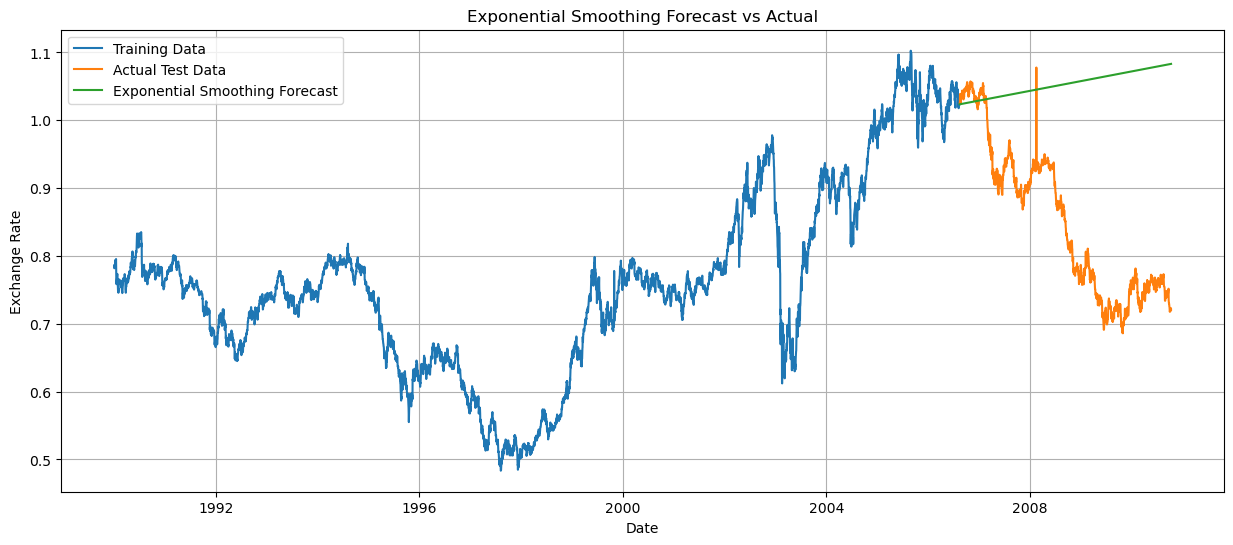

In [41]:
plt.figure(figsize=(15, 6))
plt.plot(train, label='Training Data')
plt.plot(test, label='Actual Test Data')
plt.plot(exp_forecast, label='Exponential Smoothing Forecast')
plt.title('Exponential Smoothing Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)

plt.show()

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
# ARIMA metrics
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(
    mean_squared_error(test, arima_forecast)
)
arima_mape = np.mean(
    np.abs((test - arima_forecast) / test)
) * 100
# Exponential Smoothing metrics
exp_mae = mean_absolute_error(test, exp_forecast)
exp_rmse = np.sqrt(
    mean_squared_error(test, exp_forecast)
)
exp_mape = np.mean(
    np.abs((test - exp_forecast) / test)
) * 100

In [43]:
results = pd.DataFrame({
    'Model': ['ARIMA', 'Exponential Smoothing'],
    'MAE': [arima_mae, exp_mae],
    'RMSE': [arima_rmse, exp_rmse],
    'MAPE (%)': [arima_mape, exp_mape]
})
results

,Model,MAE,RMSE,MAPE (%)
0,ARIMA,0.177710,0.205437,22.797966
1,Exponential Smoothing,0.206596,0.239104,26.508664


In [44]:
# Find the best model based on RMSE
best_model = results.loc[
    results['RMSE'].idxmin(), 
    'Model'
]
print("Best Model based on RMSE:", best_model)

Best Model based on RMSE: ARIMA


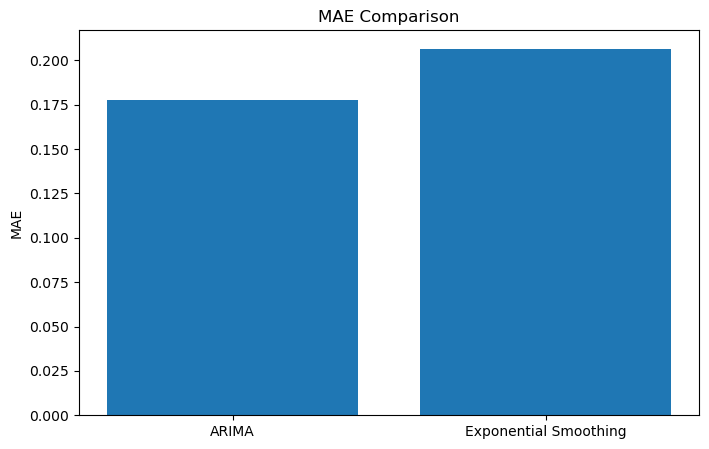

In [45]:
#compare MAE
plt.figure(figsize=(8, 5))
plt.bar(results['Model'], results['MAE'])
plt.title('MAE Comparison')
plt.ylabel('MAE')
plt.show()

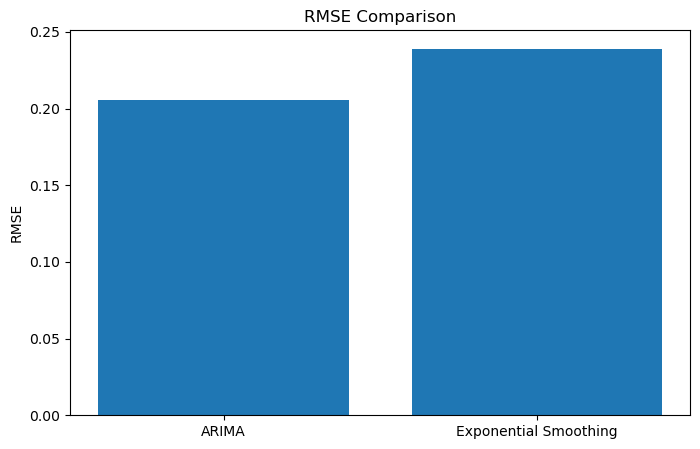

In [46]:
#compare RMSE
plt.figure(figsize=(8, 5))
plt.bar(results['Model'], results['RMSE'])
plt.title('RMSE Comparison')
plt.ylabel('RMSE')
plt.show()

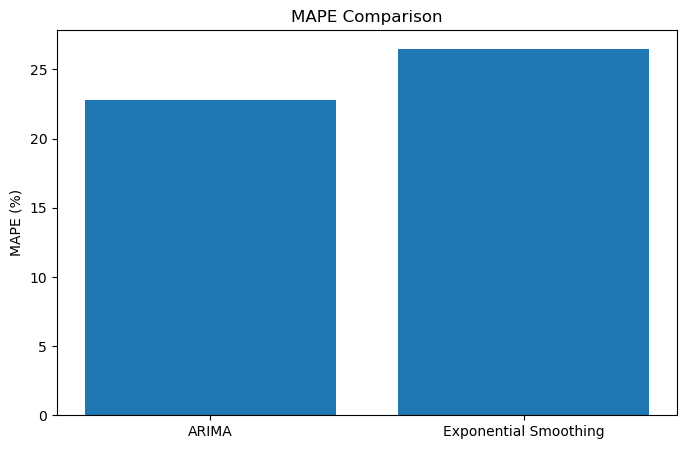

In [47]:
#compare MAPE
plt.figure(figsize=(8, 5))
plt.bar(results['Model'], results['MAPE (%)'])
plt.title('MAPE Comparison')
plt.ylabel('MAPE (%)')
plt.show()

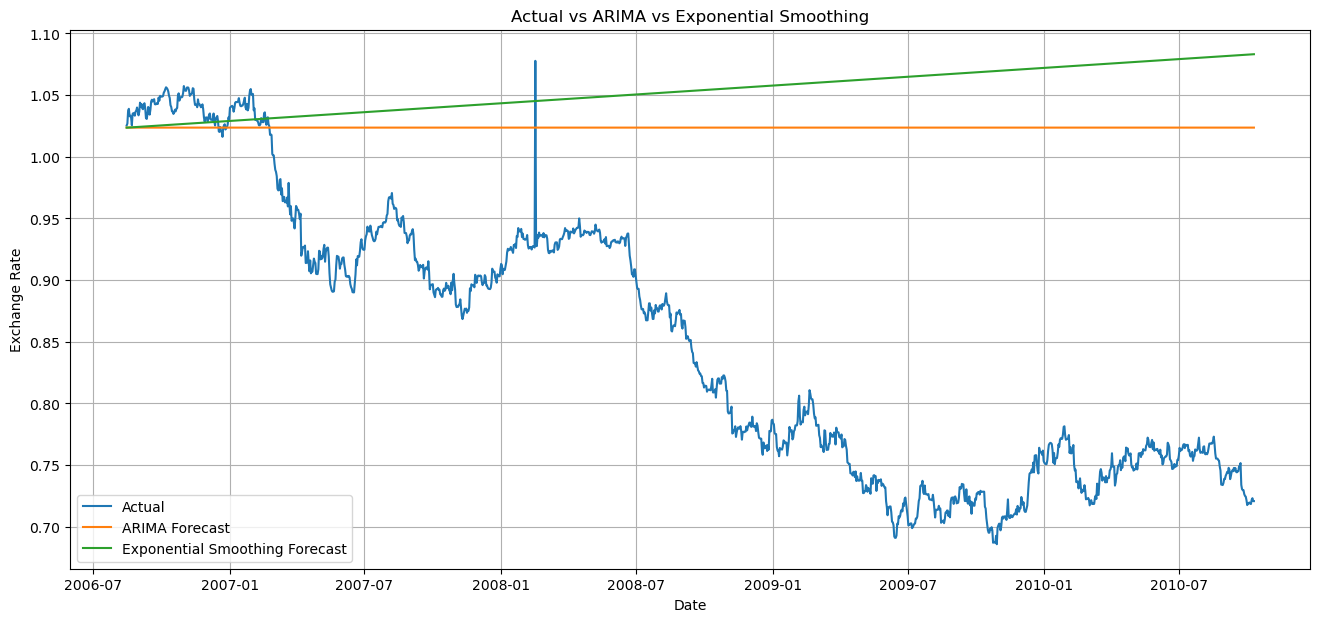

In [48]:
#final comparision 
plt.figure(figsize=(16, 7))
plt.plot(test, label='Actual')
plt.plot(arima_forecast, label='ARIMA Forecast')
plt.plot(exp_forecast, label='Exponential Smoothing Forecast')
plt.title('Actual vs ARIMA vs Exponential Smoothing')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()


Conclusion:

The exchange rate time series was analyzed using ARIMA and
Exponential Smoothing techniques.

The models were evaluated using MAE, RMSE and MAPE.
Lower values of these metrics indicate better forecasting performance.

Based on the evaluation results, the model with the lowest error
metrics provides better forecasting performance for this dataset.

ARIMA is useful for modeling autocorrelation and differenced
time-series patterns, while Exponential Smoothing is useful for
capturing level and trend components.

The final model can be selected based on its forecasting accuracy
and residual diagnostics.
